In [1]:
!pip install yfinance ta mplfinance scikit-learn joblib -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import mplfinance as mpf

from ta.trend import MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

plt.style.use("ggplot")

In [3]:
df = yf.download(
    "TSLA",
    start="2014-01-01",
    progress=False,
    auto_adjust=False
)

In [4]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.reset_index(inplace=True)

In [5]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2014-01-02,10.006667,10.006667,10.165333,9.770000,9.986667,92826000
1,2014-01-03,9.970667,9.970667,10.146000,9.906667,10.000000,70425000
2,2014-01-06,9.800000,9.800000,10.026667,9.682667,10.000000,80416500
3,2014-01-07,9.957333,9.957333,10.026667,9.683333,9.841333,75511500
4,2014-01-08,10.085333,10.085333,10.246667,9.917333,9.923333,92448000


In [6]:
df.shape

(3151, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3151 entries, 0 to 3150
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       3151 non-null   datetime64[ns]
 1   Adj Close  3151 non-null   float64       
 2   Close      3151 non-null   float64       
 3   High       3151 non-null   float64       
 4   Low        3151 non-null   float64       
 5   Open       3151 non-null   float64       
 6   Volume     3151 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 172.4 KB


In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Price,,,,,,,,
Date,3151,2020-04-05 09:44:02.589654016,2014-01-02 00:00:00,2017-02-16 12:00:00,2020-04-06 00:00:00,2023-05-22 12:00:00,2026-07-15 00:00:00,NaN
Adj Close,3151.0,138.961221,9.289333,16.767334,50.259335,245.381668,489.880005,138.741492
Close,3151.0,138.961221,9.289333,16.767334,50.259335,245.381668,489.880005,138.741492
High,3151.0,141.965803,9.8,16.998667,52.409332,251.236664,498.829987,141.709473
Low,3151.0,135.833996,9.111333,16.531667,48.315334,240.629997,485.329987,135.709604
Open,3151.0,138.989829,9.366667,16.765667,50.333332,245.065002,489.880005,138.829772
Volume,3151.0,108146474.769914,10620000.0,65377500.0,89884500.0,125202650.0,914082000.0,69939213.385261


In [9]:
df.sample(5)

Price,Date,Adj Close,Close,High,Low,Open,Volume
2116,2022-05-27,253.210007,253.210007,253.266663,240.176666,241.083328,89295000
1549,2020-02-28,44.532665,44.532665,46.034668,40.768002,41.980000,363343500
133,2014-07-15,14.638667,14.638667,15.176667,14.540000,15.115333,85777500
1736,2020-11-23,173.949997,173.949997,175.333328,167.263336,167.833328,150780900
2927,2025-08-22,340.010010,340.010010,340.250000,319.690002,321.660004,94016300


In [10]:
df.isnull().sum()

Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['Date']=pd.to_datetime(df['Date'])

In [14]:
df=df.sort_values("Date")

In [15]:
df.reset_index(drop=True,inplace=True)

In [16]:
df.to_csv("TSLA.csv",index=False)

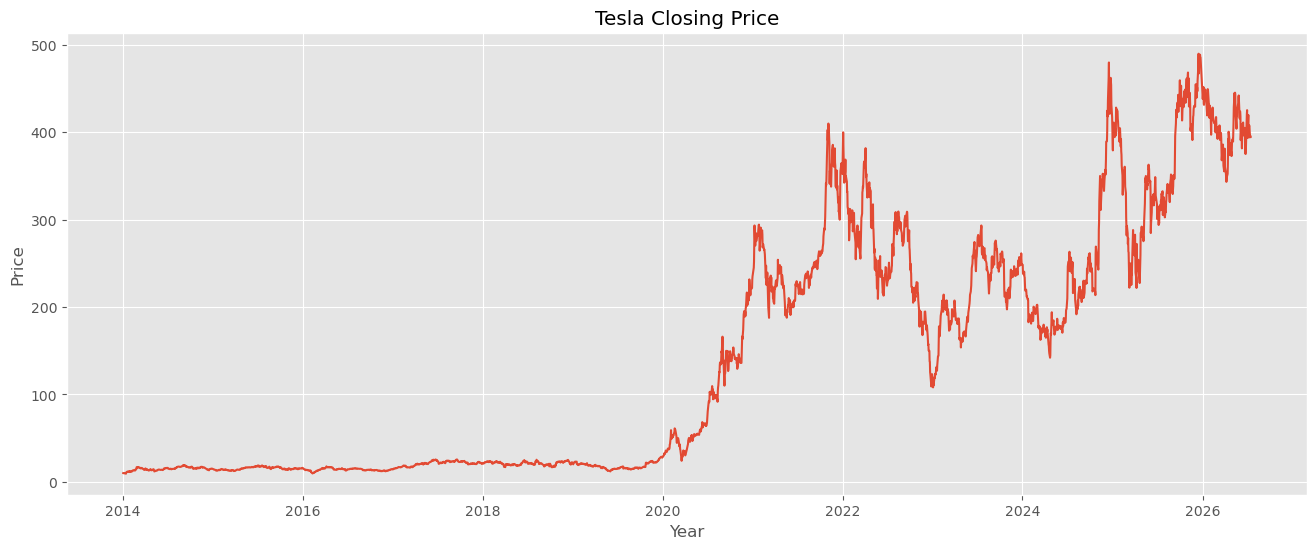

In [17]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"],df["Close"])

plt.title("Tesla Closing Price")

plt.xlabel("Year")

plt.ylabel("Price")

plt.show()

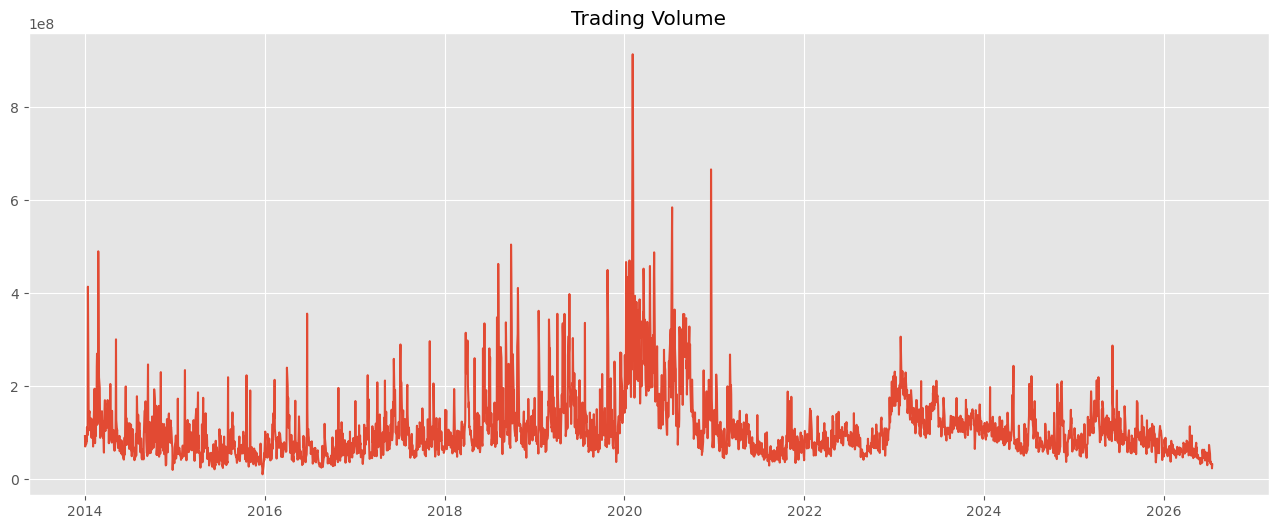

In [18]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"],df["Volume"])

plt.title("Trading Volume")

plt.show()

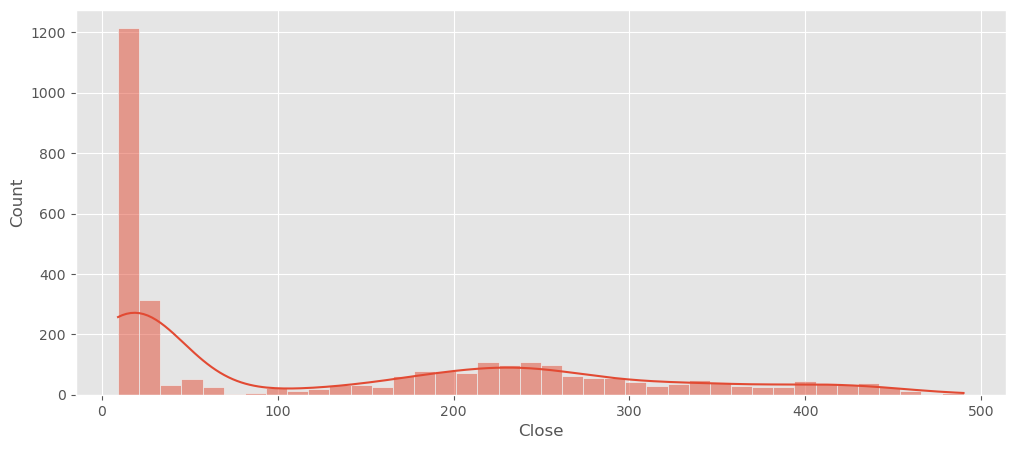

In [19]:
plt.figure(figsize=(12,5))

sns.histplot(df["Close"],bins=40,kde=True)

plt.show()

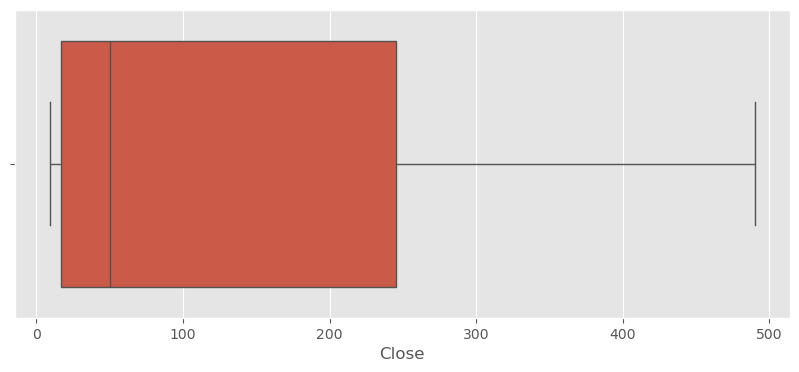

In [20]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Close"])

plt.show()

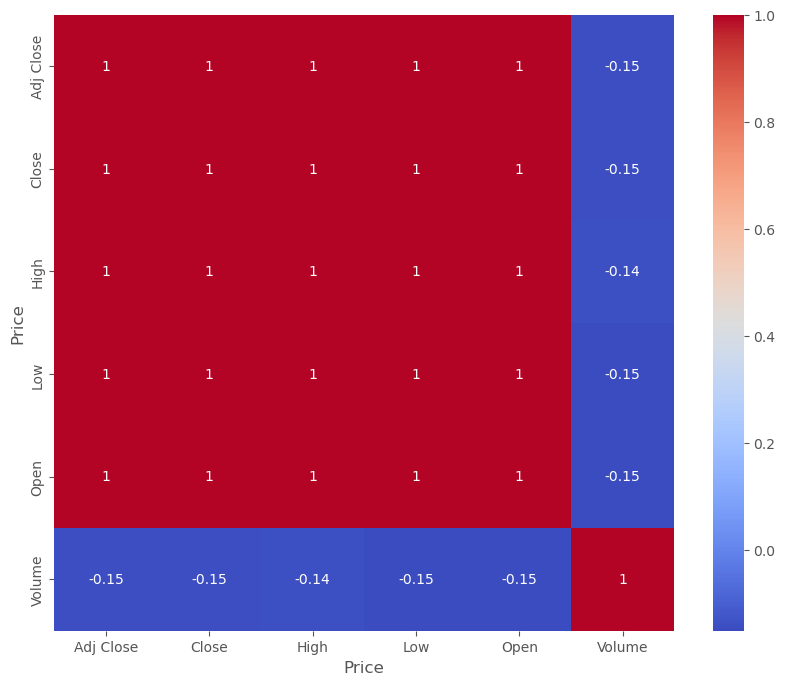

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

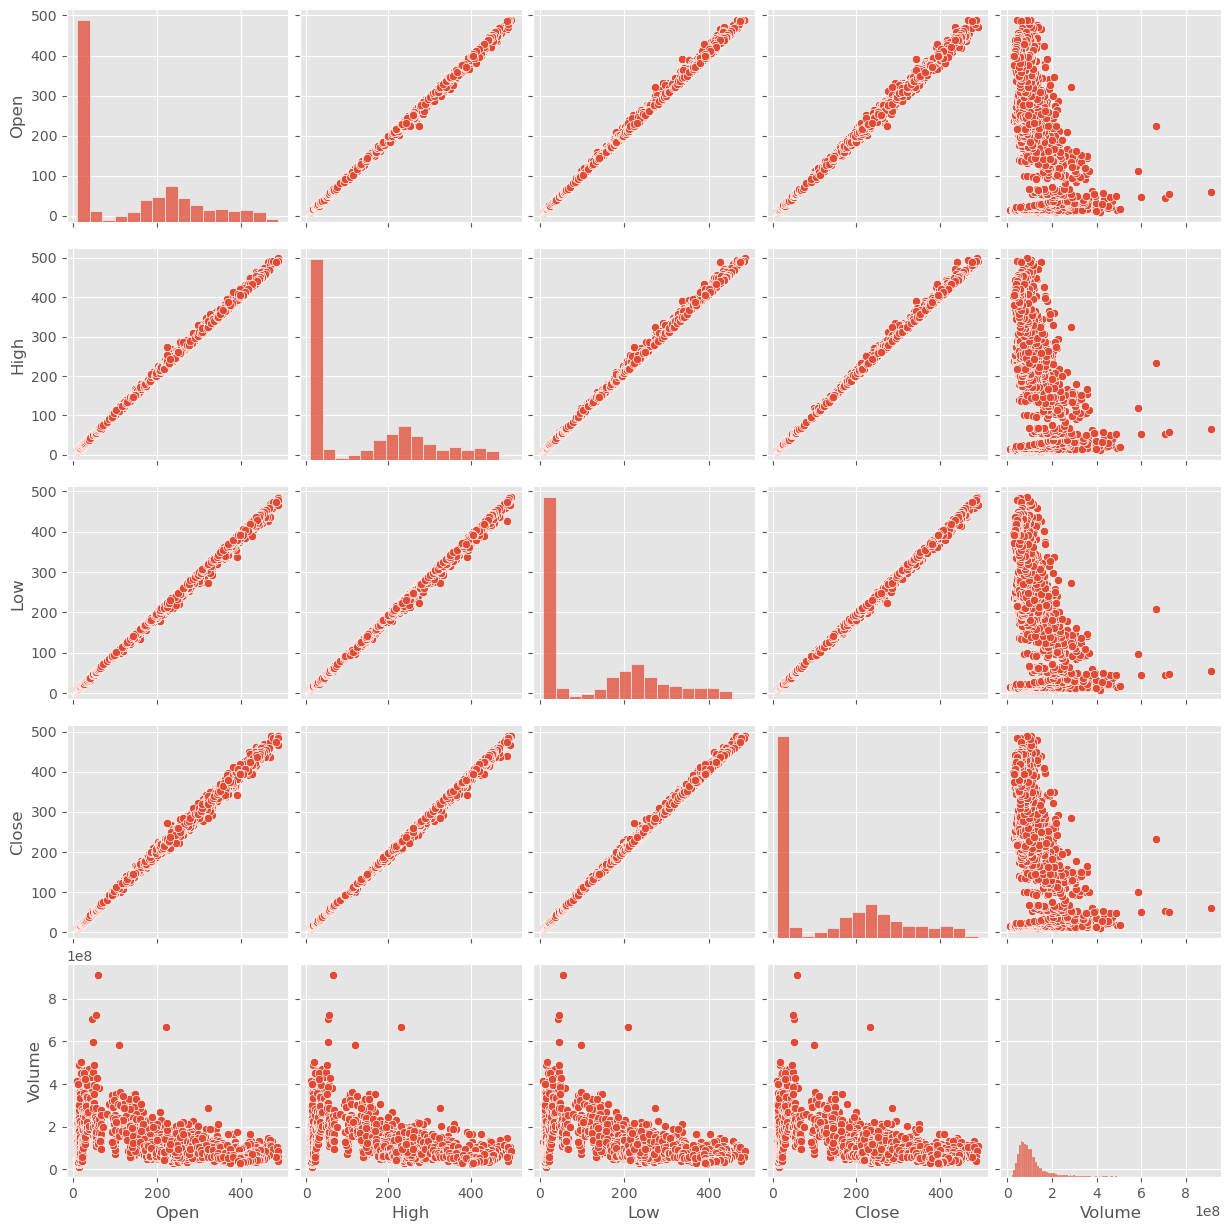

In [22]:
sns.pairplot(
    df[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "Volume"
        ]
    ]
)

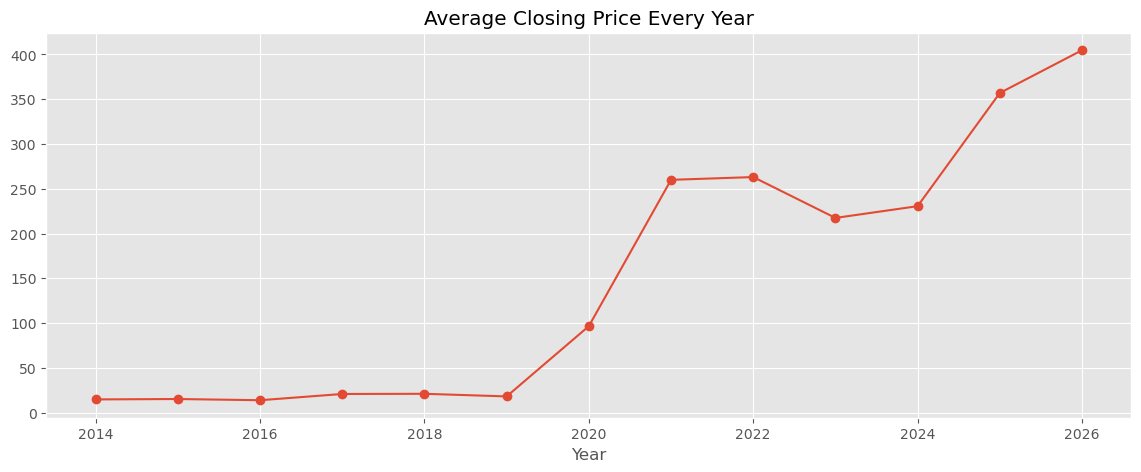

In [23]:
df["Year"]=df["Date"].dt.year

year=df.groupby("Year")["Close"].mean()

year.plot(figsize=(14,5),marker="o")

plt.title("Average Closing Price Every Year")

plt.show()

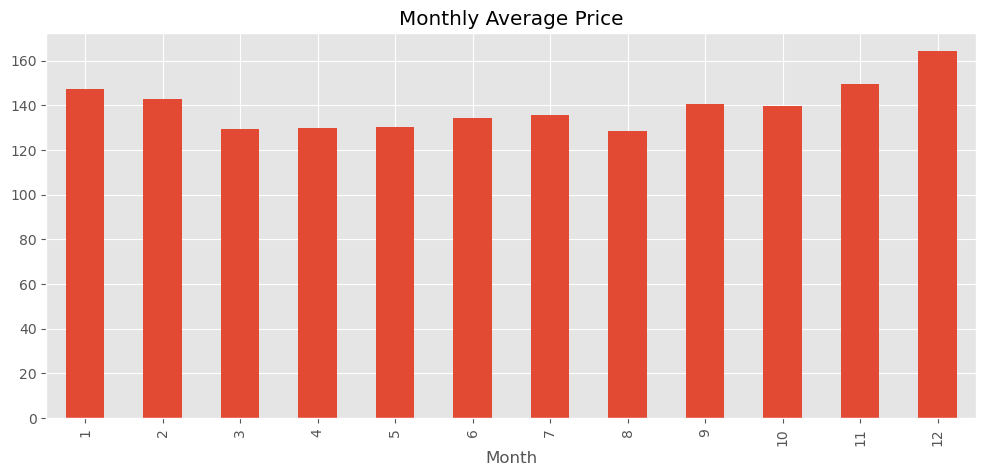

In [24]:
df["Month"]=df["Date"].dt.month

month=df.groupby("Month")["Close"].mean()

month.plot(kind="bar",figsize=(12,5))

plt.title("Monthly Average Price")

plt.show()

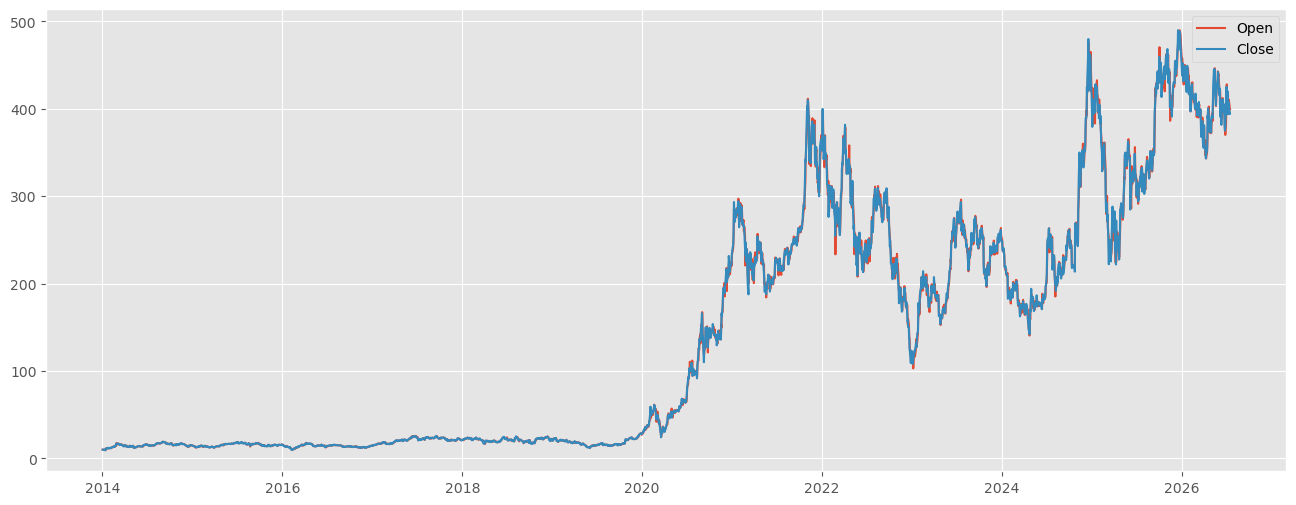

In [25]:
plt.figure(figsize=(16,6))

plt.plot(df["Date"],df["Open"],label="Open")

plt.plot(df["Date"],df["Close"],label="Close")

plt.legend()

plt.show()

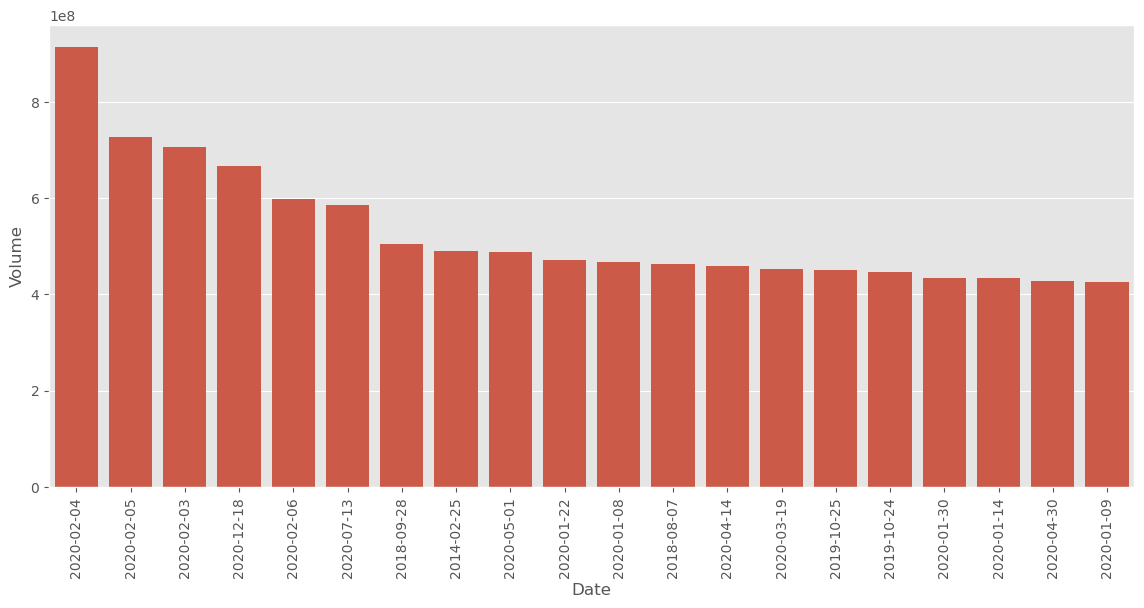

In [26]:
top=df.nlargest(20,"Volume")

plt.figure(figsize=(14,6))

sns.barplot(
    data=top,
    x="Date",
    y="Volume"
)

plt.xticks(rotation=90)

plt.show()

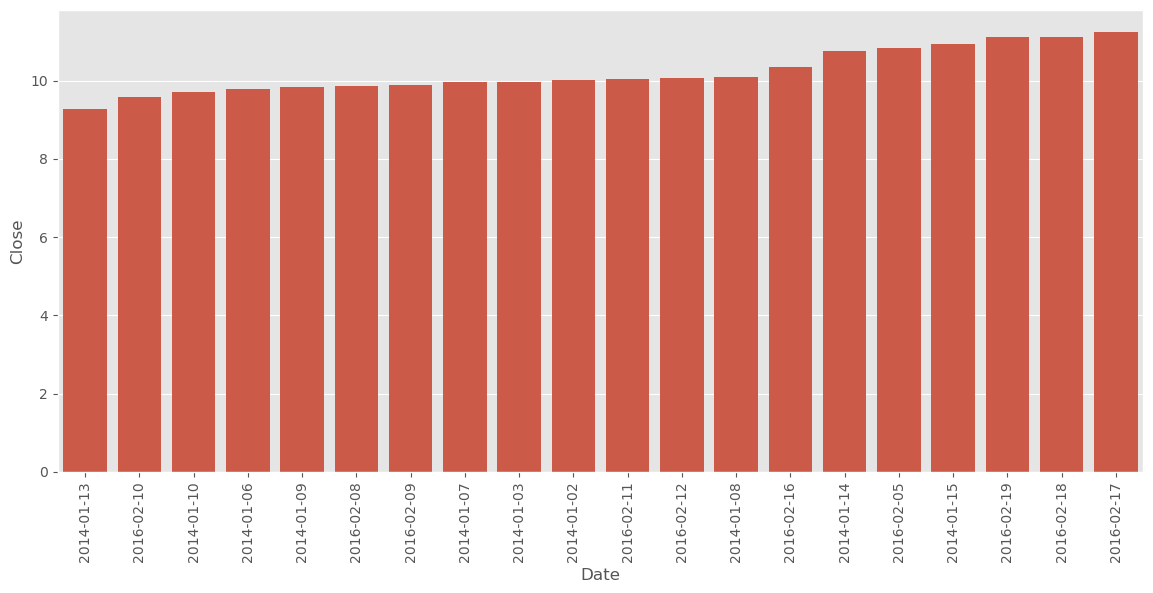

In [27]:
lowest=df.nsmallest(20,"Close")

plt.figure(figsize=(14,6))

sns.barplot(
    data=lowest,
    x="Date",
    y="Close"
)

plt.xticks(rotation=90)

plt.show()

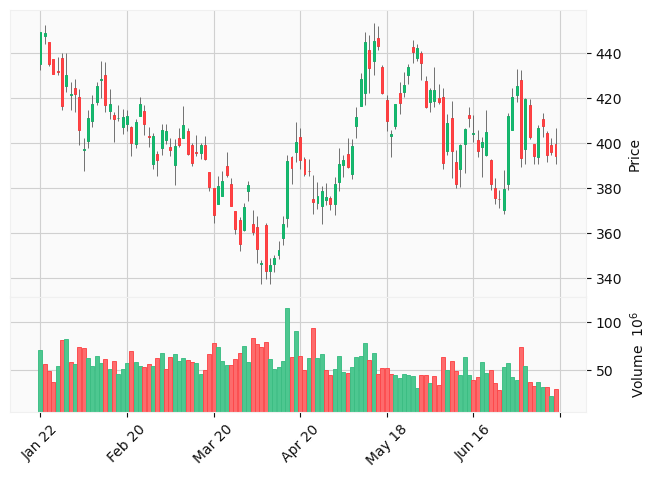

In [28]:
temp=df.copy()

temp.set_index("Date",inplace=True)

mpf.plot(
    temp.tail(120),
    type="candle",
    volume=True,
    style="yahoo"
)

In [29]:
df["Daily_Return"]=df["Close"].pct_change()

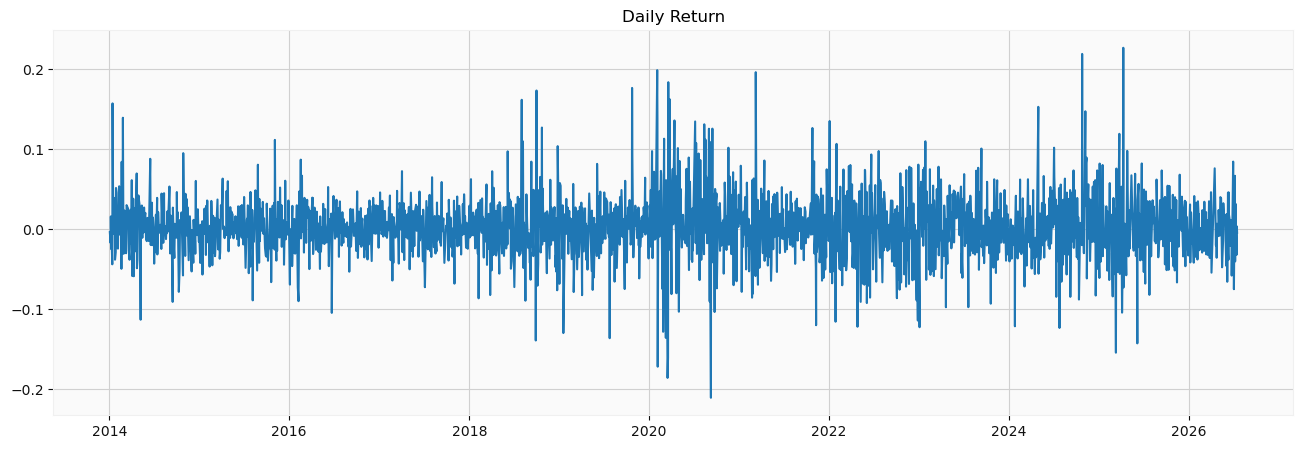

In [30]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"],df["Daily_Return"])

plt.title("Daily Return")

plt.show()

In [31]:
df["Log_Return"]=np.log(df["Close"]/df["Close"].shift(1))

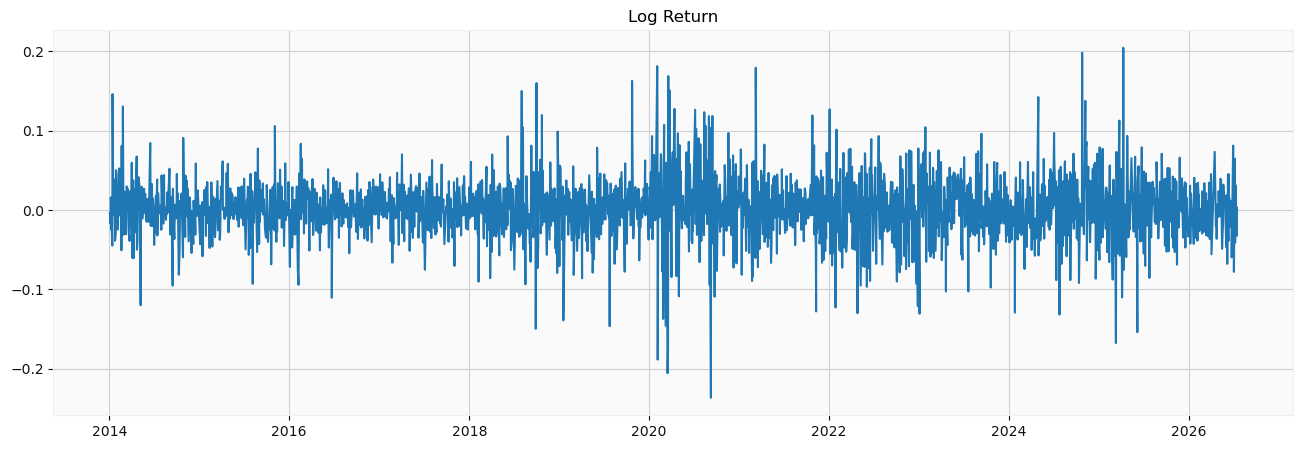

In [32]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"],df["Log_Return"])

plt.title("Log Return")

plt.show()

In [33]:
df["Price_Range"]=df["High"]-df["Low"]

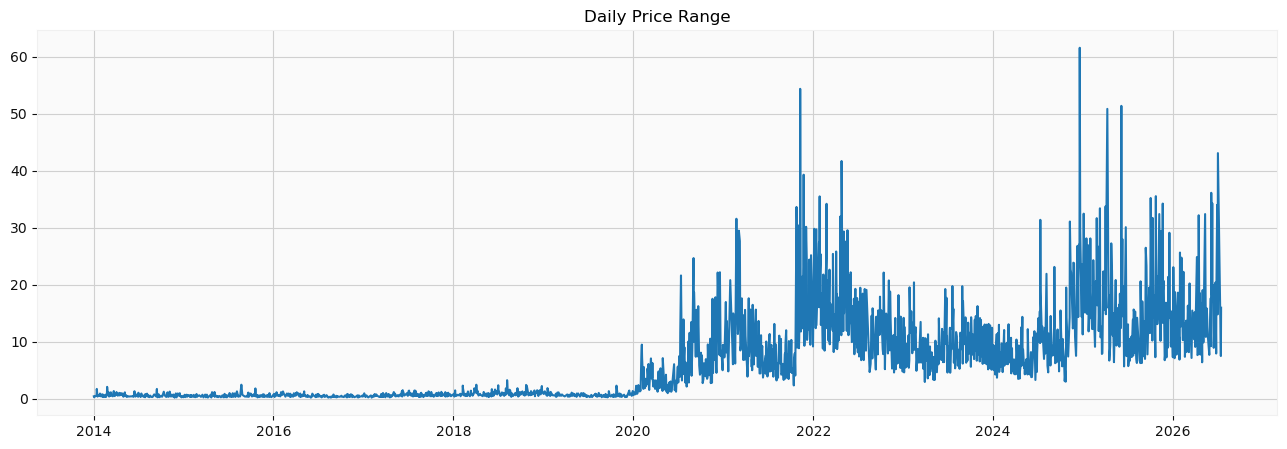

In [34]:
plt.figure(figsize=(16,5))

plt.plot(df["Date"],df["Price_Range"])

plt.title("Daily Price Range")

plt.show()

In [35]:
df["MA5"] = df["Close"].rolling(window=5).mean()
df["MA10"] = df["Close"].rolling(window=10).mean()
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

In [36]:
df["EMA10"] = df["Close"].ewm(span=10).mean()
df["EMA20"] = df["Close"].ewm(span=20).mean()
df["EMA50"] = df["Close"].ewm(span=50).mean()

In [37]:
df["Rolling_STD_5"] = df["Close"].rolling(5).std()

df["Rolling_STD_20"] = df["Close"].rolling(20).std()

In [38]:
df["Lag1"] = df["Close"].shift(1)

df["Lag2"] = df["Close"].shift(2)

df["Lag3"] = df["Close"].shift(3)

df["Lag5"] = df["Close"].shift(5)

df["Lag10"] = df["Close"].shift(10)

In [39]:
df["Price_Diff"] = df["Close"] - df["Open"]

In [40]:
df["High_Low"] = df["High"] - df["Low"]

In [41]:
df["Open_Close"] = df["Open"] - df["Close"]

In [42]:
df["Pct_Change"] = df["Close"].pct_change() * 100

In [43]:
df["Volume_Change"] = df["Volume"].pct_change() * 100

In [44]:
rsi = RSIIndicator(close=df["Close"], window=14)

df["RSI"] = rsi.rsi()

In [45]:
macd = MACD(close=df["Close"])

df["MACD"] = macd.macd()

df["MACD_Signal"] = macd.macd_signal()

df["MACD_Diff"] = macd.macd_diff()

In [46]:
bb = BollingerBands(close=df["Close"])

df["BB_High"] = bb.bollinger_hband()

df["BB_Low"] = bb.bollinger_lband()

df["BB_Middle"] = bb.bollinger_mavg()

In [47]:
df["Momentum"] = df["Close"] - df["Close"].shift(10)

In [48]:
df["Rolling_Max"] = df["Close"].rolling(20).max()

In [49]:
df["Rolling_Min"] = df["Close"].rolling(20).min()

In [50]:
df["Volatility"] = df["Close"].rolling(20).std()

In [51]:
df["Target"] = df["Close"].shift(-1)

In [52]:
df.dropna(inplace=True)

df.reset_index(drop=True,inplace=True)

In [53]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Daily_Return,...,MACD_Signal,MACD_Diff,BB_High,BB_Low,BB_Middle,Momentum,Rolling_Max,Rolling_Min,Volatility,Target
0,2014-03-14,15.398000,15.398000,15.796000,15.221333,15.686000,124345500,2014,3,-0.028681,...,1.083389,-0.231267,18.230933,12.914733,15.572833,-0.922668,16.989332,12.909333,1.363577,15.598667
1,2014-03-17,15.598667,15.598667,15.862000,15.366667,15.663333,88689000,2014,3,0.013032,...,1.020697,-0.250770,18.120429,13.263571,15.692000,-1.105333,16.989332,12.909333,1.245758,16.002666
2,2014-03-18,16.002666,16.002666,16.100000,15.668000,15.796667,93634500,2014,3,0.025900,...,0.962354,-0.233371,18.041533,13.584733,15.813133,-0.986666,16.989332,12.909333,1.143145,15.722667
3,2014-03-19,15.722667,15.722667,16.103333,15.567333,16.092667,76069500,2014,3,-0.017497,...,0.903135,-0.236875,17.743170,14.164430,15.953800,-1.121333,16.989332,13.973333,0.917927,15.660667
4,2014-03-20,15.660667,15.660667,15.950000,15.557333,15.744000,57268500,2014,3,-0.003943,...,0.843424,-0.238844,17.594609,14.479257,16.036933,-1.202000,16.989332,13.973333,0.799071,15.259333


In [54]:
df.shape

(3101, 43)

In [55]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year',
       'Month', 'Daily_Return', 'Log_Return', 'Price_Range', 'MA5', 'MA10',
       'MA20', 'MA50', 'EMA10', 'EMA20', 'EMA50', 'Rolling_STD_5',
       'Rolling_STD_20', 'Lag1', 'Lag2', 'Lag3', 'Lag5', 'Lag10', 'Price_Diff',
       'High_Low', 'Open_Close', 'Pct_Change', 'Volume_Change', 'RSI', 'MACD',
       'MACD_Signal', 'MACD_Diff', 'BB_High', 'BB_Low', 'BB_Middle',
       'Momentum', 'Rolling_Max', 'Rolling_Min', 'Volatility', 'Target'],
      dtype='object', name='Price')

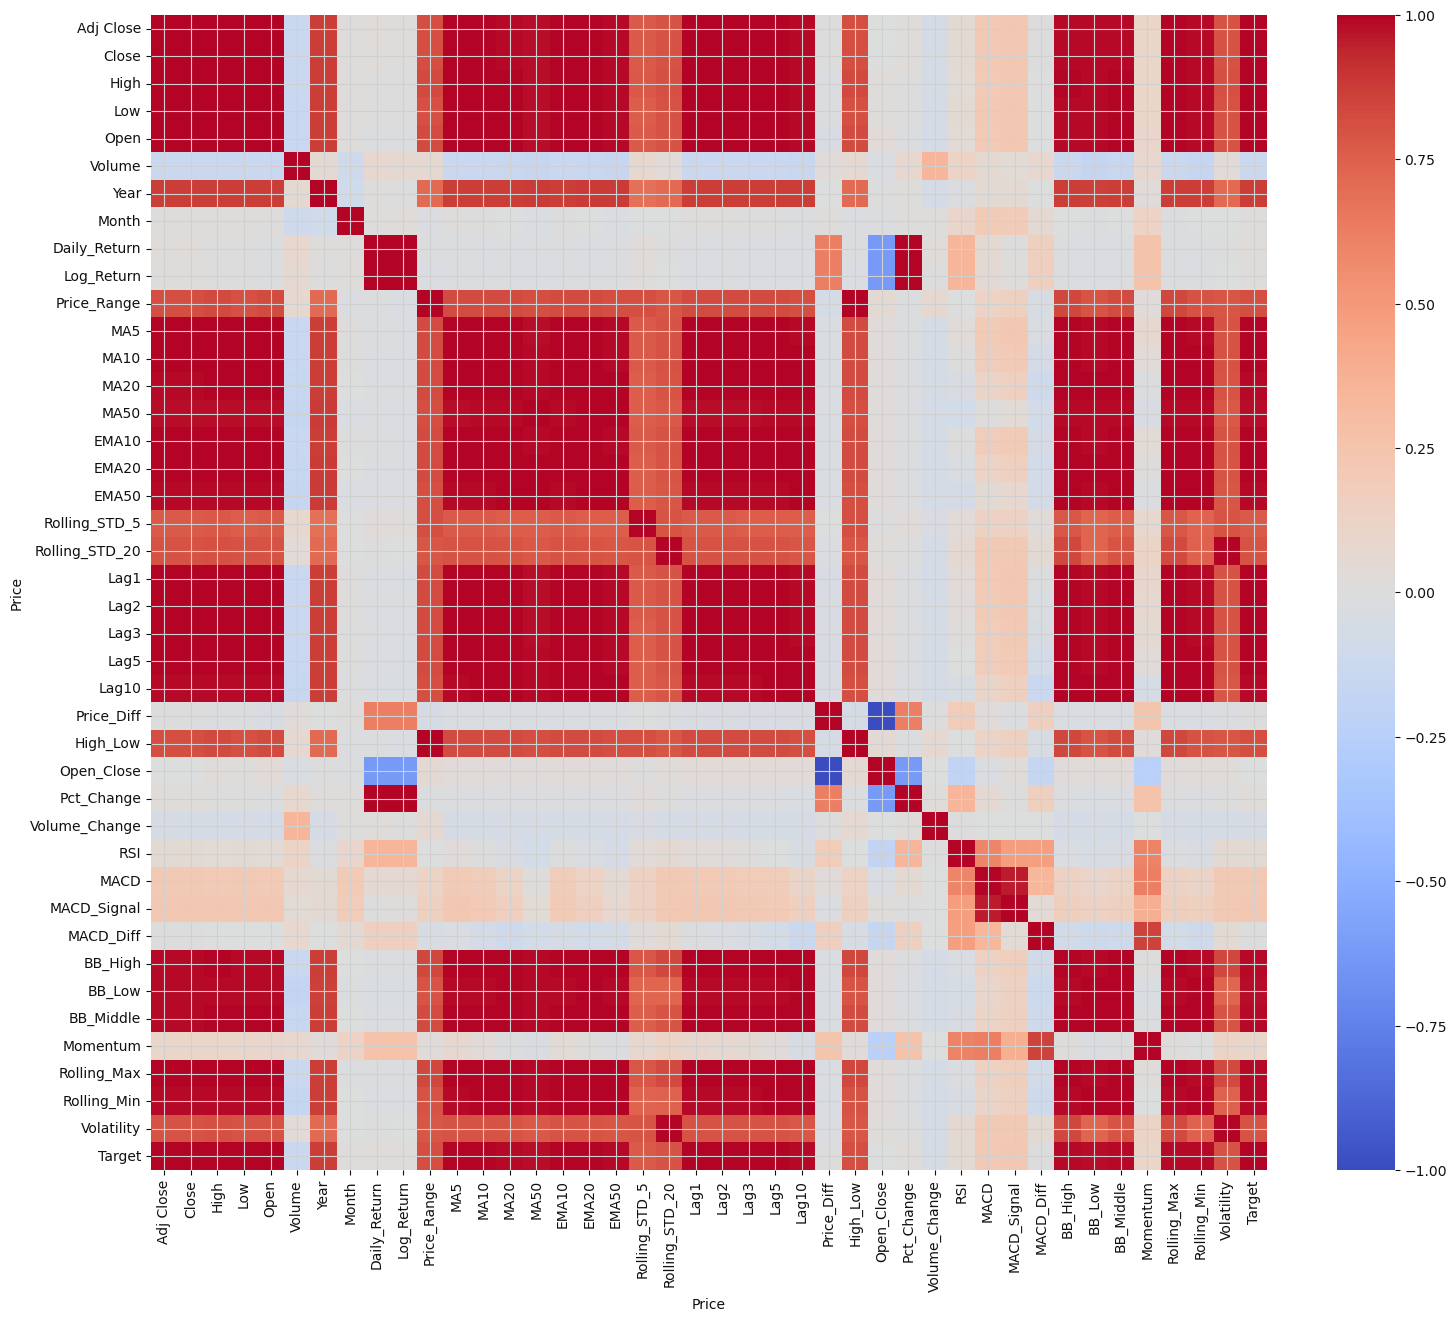

In [56]:
plt.figure(figsize=(18,15))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

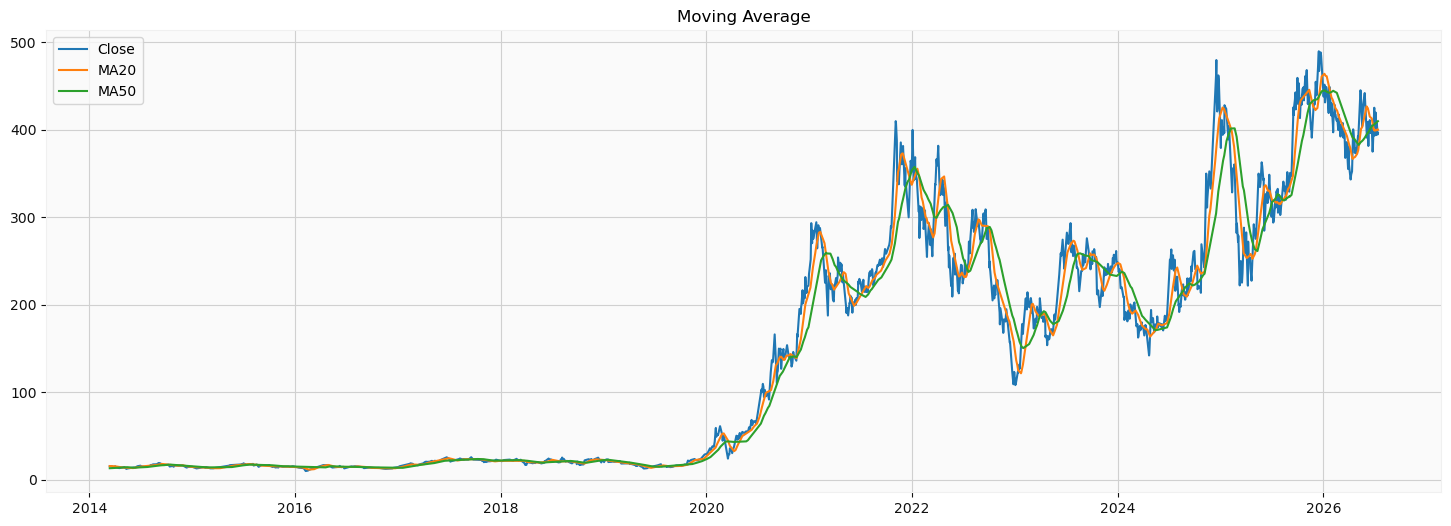

In [57]:
plt.figure(figsize=(18,6))

plt.plot(df["Date"],df["Close"],label="Close")

plt.plot(df["Date"],df["MA20"],label="MA20")

plt.plot(df["Date"],df["MA50"],label="MA50")

plt.legend()

plt.title("Moving Average")

plt.show()

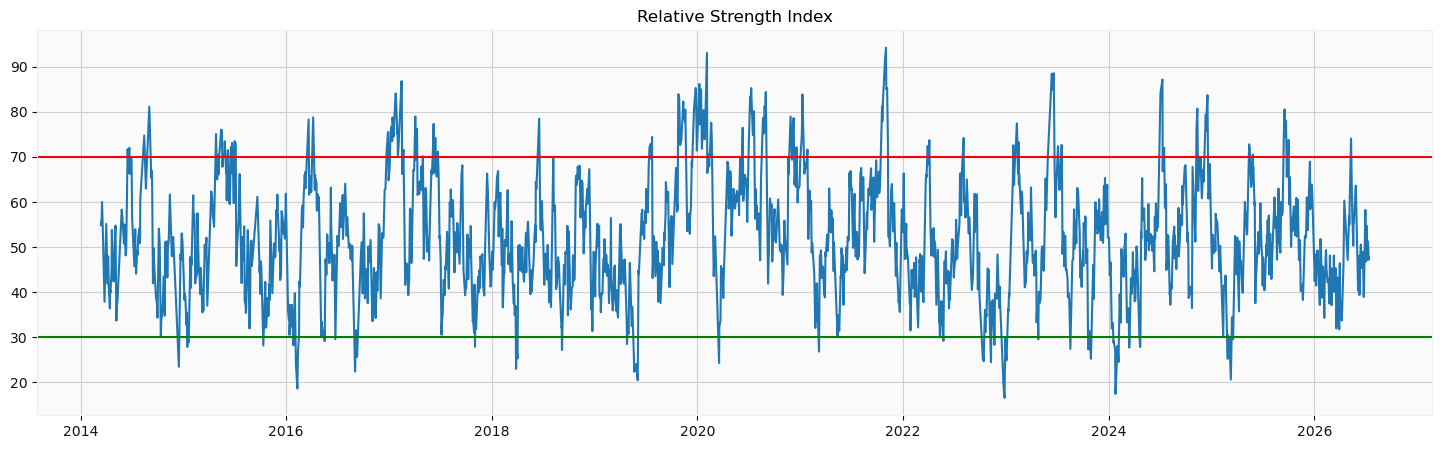

In [58]:
plt.figure(figsize=(18,5))

plt.plot(df["Date"],df["RSI"])

plt.axhline(70,color="red")

plt.axhline(30,color="green")

plt.title("Relative Strength Index")

plt.show()

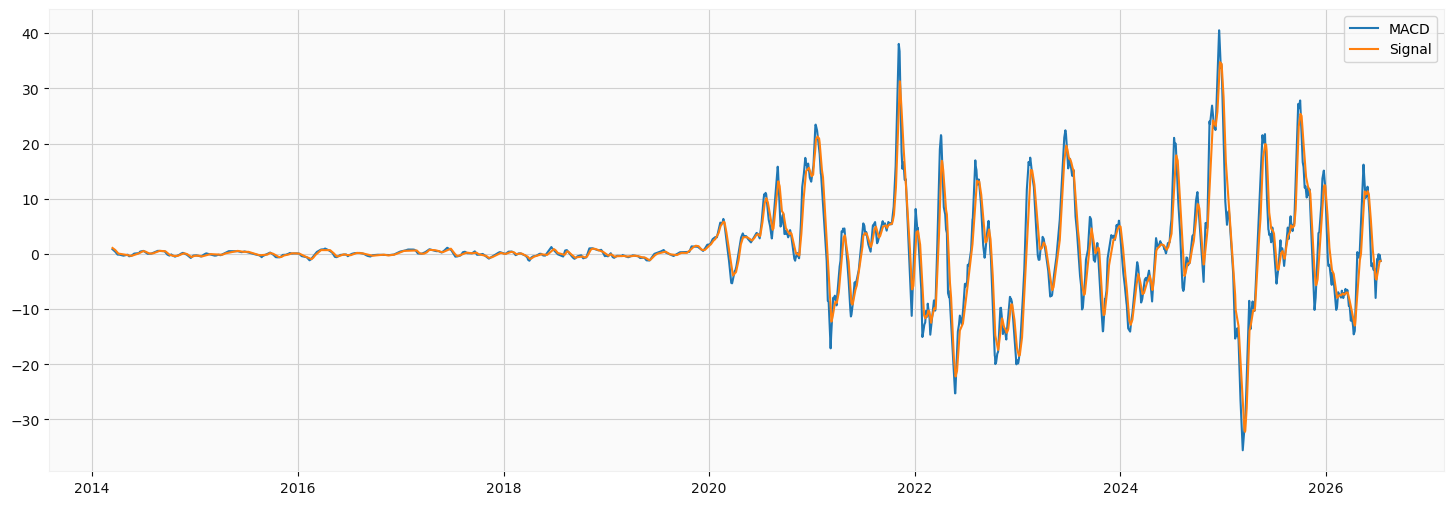

In [59]:
plt.figure(figsize=(18,6))

plt.plot(df["Date"],df["MACD"],label="MACD")

plt.plot(df["Date"],df["MACD_Signal"],label="Signal")

plt.legend()

plt.show()

In [60]:
df.to_csv("TSLA_Feature_Engineered.csv",index=False)

In [61]:
X = df.drop(columns=["Date", "Target"])

y = df["Target"]

In [62]:
print("X Shape :", X.shape)

print("Y Shape :", y.shape)

X Shape : (3101, 41)
Y Shape : (3101,)


In [63]:
split = int(len(df) * 0.80)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [64]:
print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 2480
Testing Samples : 621


In [65]:
## Linear Regression

In [66]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [67]:
lr_pred = lr.predict(X_test)

In [68]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)

print("RMSE :", lr_rmse)

print("R2 :", lr_r2)

MAE : 8.569681149618503
RMSE : 11.548222336696437
R2 : 0.9856079828831077


In [69]:
## Decision Tree

In [70]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=8
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [71]:
dt_pred = dt.predict(X_test)

In [72]:
dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print(dt_mae)

print(dt_rmse)

print(dt_r2)

29.465521390649393
43.19439522702799
0.7986525244378834


In [73]:
## Random Forest

In [74]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [75]:
rf_pred = rf.predict(X_test)

In [76]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print(rf_mae)

print(rf_rmse)

print(rf_r2)

25.083078998743815
36.70341419400521
0.8546201143774723


In [77]:
## Hyperparameter Tuning

In [78]:
tscv = TimeSeriesSplit(n_splits=5)

In [79]:
params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5]

}

In [80]:
grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    params,

    cv=tscv,

    scoring="r2",

    n_jobs=-1

)

In [81]:
grid.fit(X_train,y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [82]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [83]:
best_model = grid.best_estimator_

In [84]:
best_pred = best_model.predict(X_test)

In [85]:
best_mae = mean_absolute_error(y_test,best_pred)

best_rmse = np.sqrt(mean_squared_error(y_test,best_pred))

best_r2 = r2_score(y_test,best_pred)

print(best_mae)

print(best_rmse)

print(best_r2)

24.788037417407402
36.298605022435474
0.8578092765908272


In [86]:
## Model Comparison

In [87]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "Best Random Forest"

    ],

    "MAE":[

        lr_mae,

        dt_mae,

        rf_mae,

        best_mae

    ],

    "RMSE":[

        lr_rmse,

        dt_rmse,

        rf_rmse,

        best_rmse

    ],

    "R2 Score":[

        lr_r2,

        dt_r2,

        rf_r2,

        best_r2

    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.569681,11.548222,0.985608
1,Decision Tree,29.465521,43.194395,0.798653
2,Random Forest,25.083079,36.703414,0.854620
3,Best Random Forest,24.788037,36.298605,0.857809


In [88]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.569681,11.548222,0.985608
3,Best Random Forest,24.788037,36.298605,0.857809
2,Random Forest,25.083079,36.703414,0.854620
1,Decision Tree,29.465521,43.194395,0.798653


In [89]:
## Feature Importanace

In [90]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

In [91]:
importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
3,Low,0.454490
1,Close,0.235121
0,Adj Close,0.213646
2,High,0.032161
20,Lag1,0.031583
4,Open,0.019678
11,MA5,0.005556
36,BB_Middle,0.001236
17,EMA50,0.001052
14,MA50,0.001049


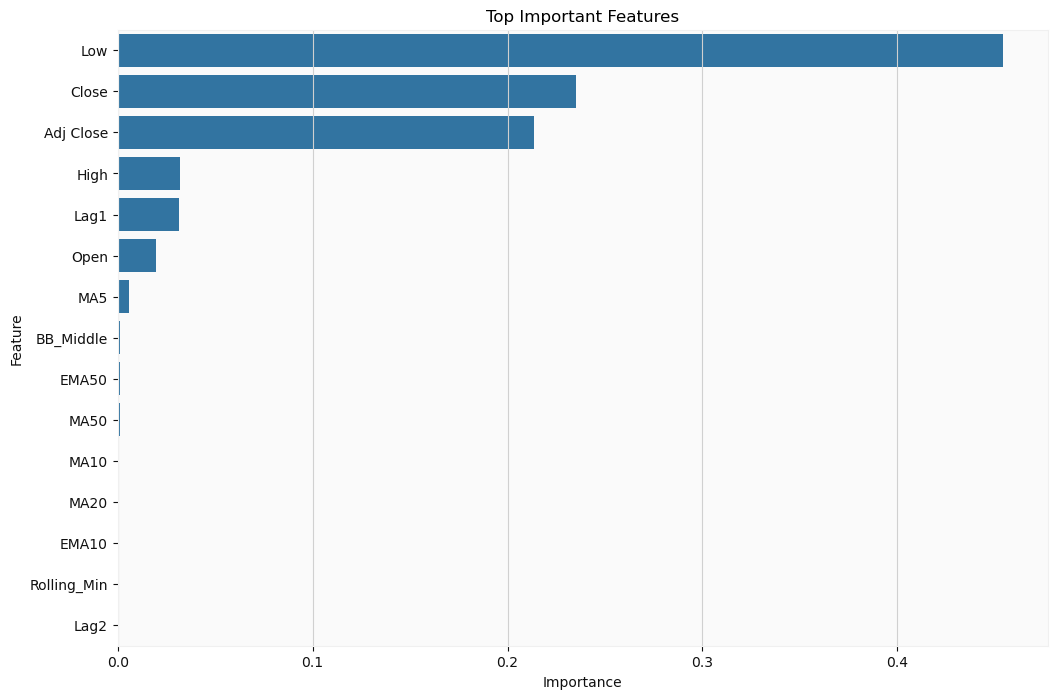

In [92]:
plt.figure(figsize=(12,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top Important Features")

plt.show()

In [93]:
## Predicted Graph

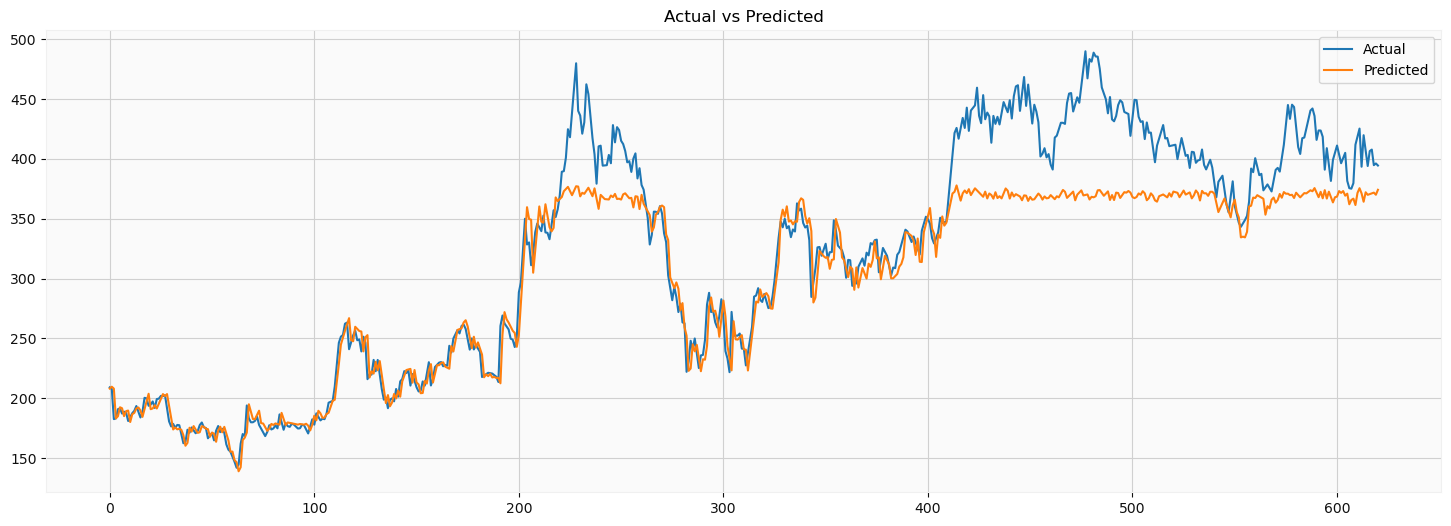

In [94]:
plt.figure(figsize=(18,6))

plt.plot(

    y_test.values,

    label="Actual"

)

plt.plot(

    best_pred,

    label="Predicted"

)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

In [95]:
result = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":best_pred

})

result.head(20)

,Actual,Predicted
0,209.139999,208.152299
1,207.830002,209.706599
2,182.630005,208.104329
3,183.250000,183.252911
4,190.929993,185.050871
5,191.589996,192.535914
6,187.289993,191.766169
7,188.860001,185.128569
8,187.910004,189.342886
9,181.059998,189.783381


In [96]:
result.tail(20)

,Actual,Predicted
601,404.660004,373.099518
602,396.380005,371.595739
603,400.489990,373.108473
604,405.049988,369.290496
605,381.609985,370.967010
606,375.529999,362.091182
607,375.119995,365.677287
608,379.709991,366.802650
609,411.839996,361.460554
610,420.600006,371.541763


In [97]:
## Residual Analysis

In [98]:
residual = y_test.values - best_pred

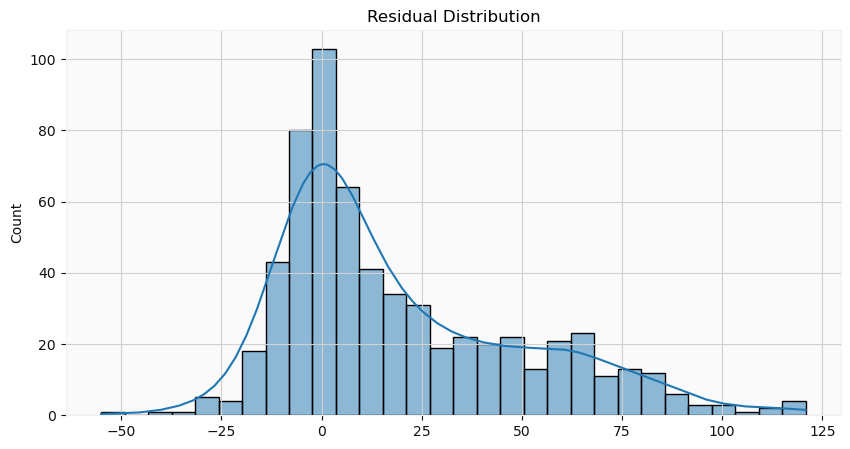

In [99]:
plt.figure(figsize=(10,5))

sns.histplot(

    residual,

    bins=30,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

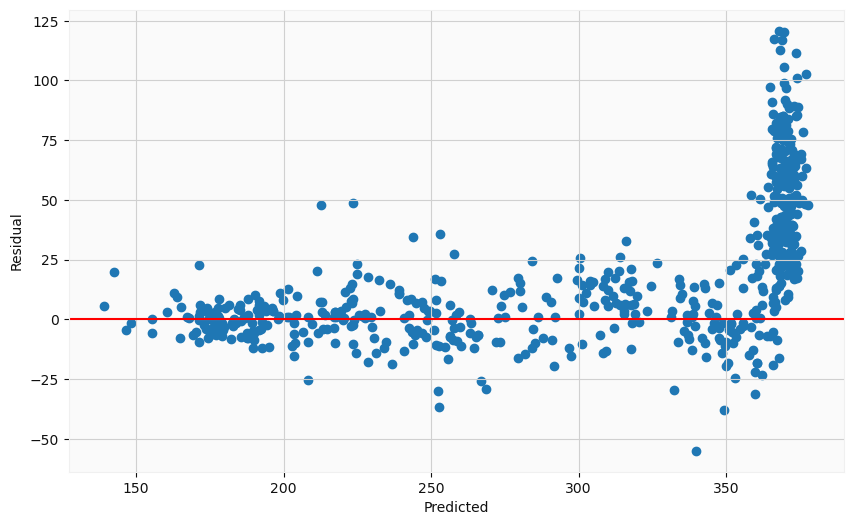

In [100]:
plt.figure(figsize=(10,6))

plt.scatter(

    best_pred,

    residual

)

plt.axhline(

    y=0,

    color="red"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.show()

In [101]:
joblib.dump(

    best_model,

    "Tesla_Stock_Prediction_Model.pkl"

)

['Tesla_Stock_Prediction_Model.pkl']

In [102]:
print("Model Saved Successfully")

Model Saved Successfully


In [103]:
loaded_model = joblib.load(
    "Tesla_Stock_Prediction_Model.pkl"
)

In [104]:
prediction = loaded_model.predict(X.tail(5))

prediction

array([370.53675041, 371.71126127, 371.81324221, 370.05657194,
       374.18965176])

In [105]:
print("="*50)
print("Tesla Stock Price Prediction Project")
print("="*50)
print()

print("Best Model :", type(best_model).__name__)

print("R2 Score :", round(best_r2,4))

print("RMSE :", round(best_rmse,4))

print("MAE :", round(best_mae,4))

print()

print("Project Completed Successfully")

Tesla Stock Price Prediction Project

Best Model : RandomForestRegressor
R2 Score : 0.8578
RMSE : 36.2986
MAE : 24.788

Project Completed Successfully
